# CHICAGO CAR CRASH PREDICTION AND ANALYSIS

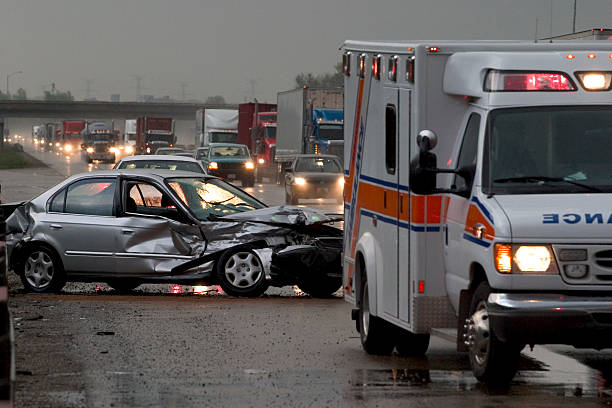


# BUSINESS UNDERSTANDING

## PROBLEM STATEMENT
Traffic accidents are a major concern in Chicago. Understanding the conditions that lead to severe crashes will help the Vehicle safety board.
This project aims to build a classification model that predicts whether a car crash will result in injuries based on environmental factors or other factors. The insights from this model will help identify high risk conditions and implement preventive measures to imrove road safety.

## Stakeholders
- Vehicle safety board
   - Responsible for road safety
   - Implement safety programs
   - They will use this model to identify high risk driving conditions and issue weather related alerts 
- City of Chicago
   - Responsible for infrastructure



## Key Questions
1. What factors contribute to most crashes?
2. Under what conditions are crashes most likely to result in injuries?
3. Can we predict whether a crash will result in injuries based on environmental conditions?
4. Can we predict the primary contributory cause of accidents?



# DATA UNDERSTANDING

The dataset we are using has been obtained from kaggle, it contains car crashes in chicago from 2019 to 2022. Its particulary useful because it includes car crash variables and environmental factors that influence crash outcomes. It allows us to analyze patterns in traffic accidents.

#### Importing libraries

In [20]:
# Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models and evaluation matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
 
 

#### Loading the dataset

In [21]:
df=pd.read_csv("chicago_2019_2022.csv")

C:\Users\Dell\AppData\Local\Temp\ipykernel_17420\2883874868.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("chicago_2019_2022.csv")


#### Loads the dataset into pandas dataframe so that we can explore and manipulate it

#### Data inspection

In [22]:
df.head()

,id,crash_date,crash_time,town,city,state,country,total_injured,total_killed,injury_incapacitated,...,windgust,windspeed,winddir,pressure,visibility,cloudcover,conditions,sunrise,sunset,moonphase
0,200319661,07/18/19,10:35,harwood heights,chicago,illinois,usa,0,0,0,...,\N,6.9,193.0,1013.9,1.8,54.6,"Rain, Partially cloudy",5:31:20,20:23:09,0.56
1,200320852,07/21/19,13:45,englewood,chicago,illinois,usa,0,0,0,...,\N,11.4,3.0,1013.3,7.4,87.4,"Rain, Partially cloudy",5:33:58,20:19:28,0.66
2,200320894,07/21/19,16:00,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.2,"Rain, Partially cloudy",5:33:54,20:20:12,0.66
3,200320909,07/21/19,16:45,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.3,"Rain, Partially cloudy",5:33:53,20:20:10,0.66
4,200320967,07/21/19,23:05,cicero,chicago,illinois,usa,0,0,0,...,\N,4.9,342.0,1018.4,9.9,0.0,Clear,5:34:53,20:19:06,0.69


In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print(numeric_df.columns)

Index(['id', 'num_vehicles_in_crash', 'lattitude', 'longitude', 'days_tempmax',
       'days_tempmin', 'days_temp', 'days_feelslikemax', 'days_feelslikemin',
       'days_feelslike', 'days_dew', 'days_humidity', 'days_precip',
       'days_precipprob', 'days_precipcover', 'days_windspeed', 'days_winddir',
       'days_pressure', 'days_cloudcover', 'days_visibility', 'days_uvindex',
       'days_moonphase', 'temp', 'feelslike', 'humidity', 'dew', 'precip',
       'precipprob', 'windspeed', 'winddir', 'pressure', 'visibility',
       'cloudcover', 'moonphase'],
      dtype='object')


##### Inspecting the shape of our dataset

In [24]:
df.shape

(372062, 65)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372062 entries, 0 to 372061
Data columns (total 65 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                372062 non-null  int64  
 1   crash_date                        372062 non-null  object 
 2   crash_time                        372062 non-null  object 
 3   town                              372062 non-null  object 
 4   city                              372062 non-null  object 
 5   state                             372062 non-null  object 
 6   country                           372062 non-null  object 
 7   total_injured                     372062 non-null  object 
 8   total_killed                      372062 non-null  object 
 9   injury_incapacitated              372062 non-null  object 
 10  injury_non_incapacitated          372062 non-null  object 
 11  most_severe_injury                372062 non-null  o

#### These commands help us understand the dataset. 
 - .head()- returns the first 5 rows to inspect columns
- .shape- shows the total number of rows and columns
- .info()- shows the column names , data tyoes and missing values

#### Box plot to check outliers

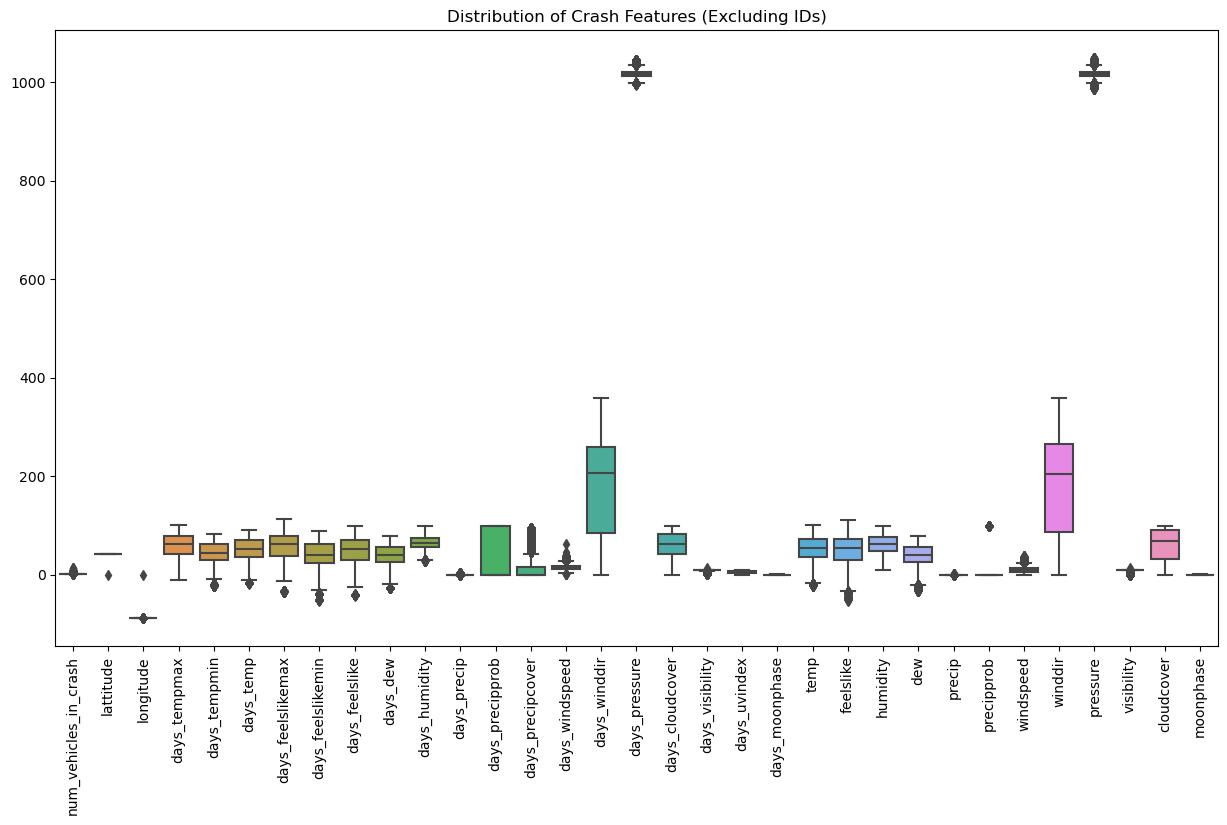

In [26]:

# Create a list of columns to exclude (anything with huge numbers like IDs)
# We also exclude 'total_injured' since it was your "leakage" column
exclude_cols = ['id', 'total_injured', 'total_killed']

# Filter the dataframe
df_to_plot = df.select_dtypes(include=['number']).drop(columns=exclude_cols, errors='ignore')

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_to_plot)
plt.xticks(rotation=90) # This makes the labels readable
plt.title("Distribution of Crash Features (Excluding IDs)")
plt.show()

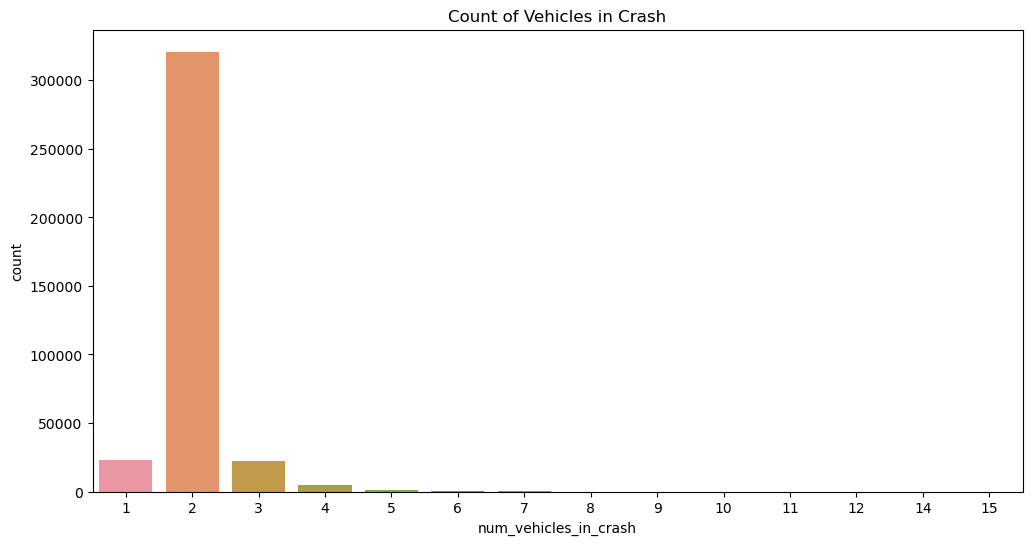

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


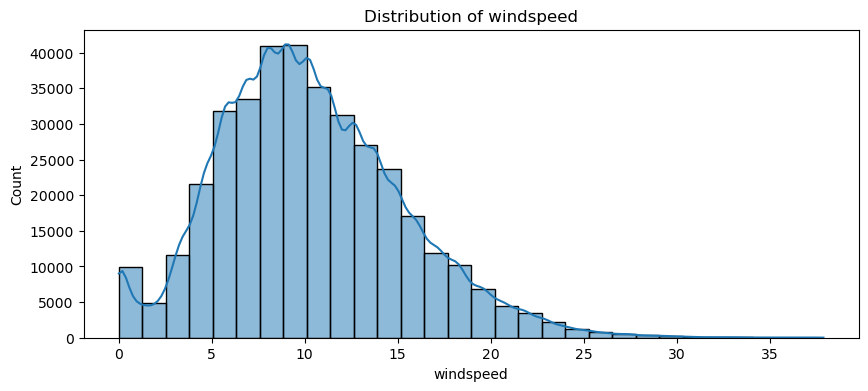

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


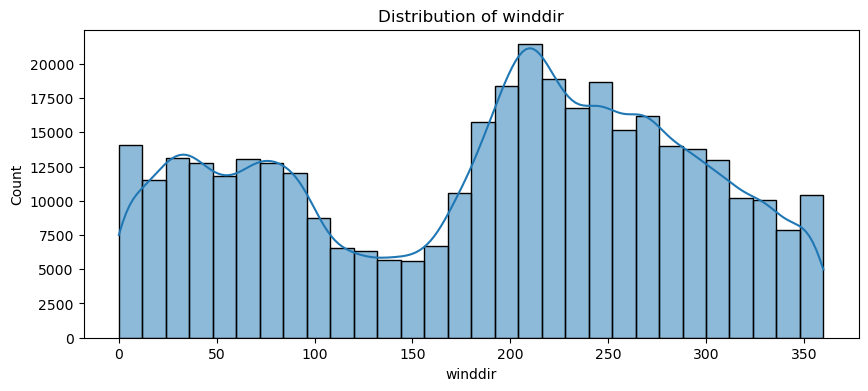

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


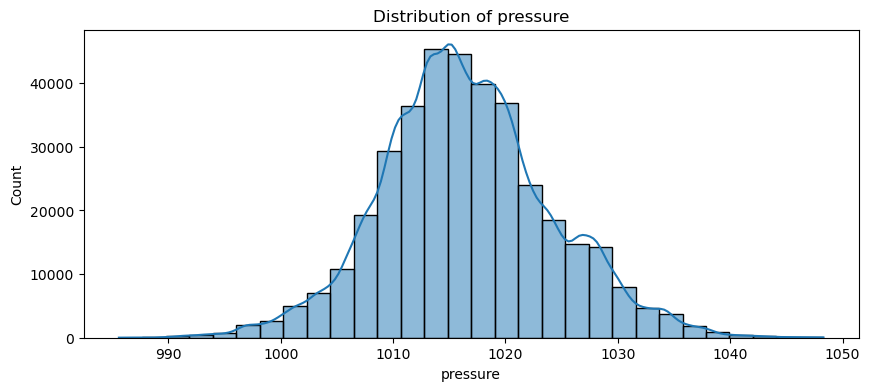

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


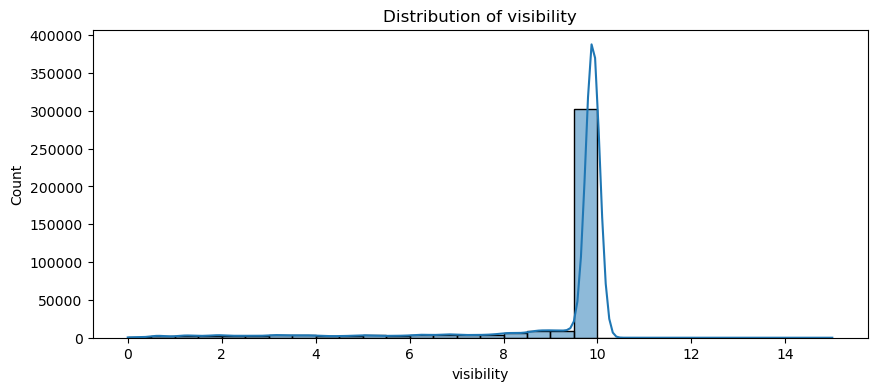

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


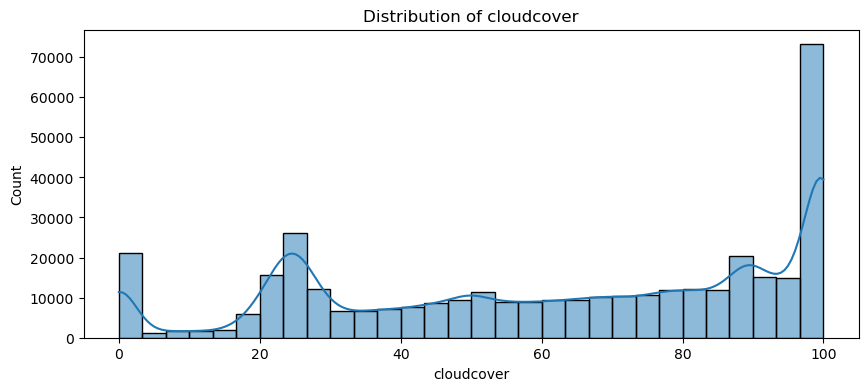

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


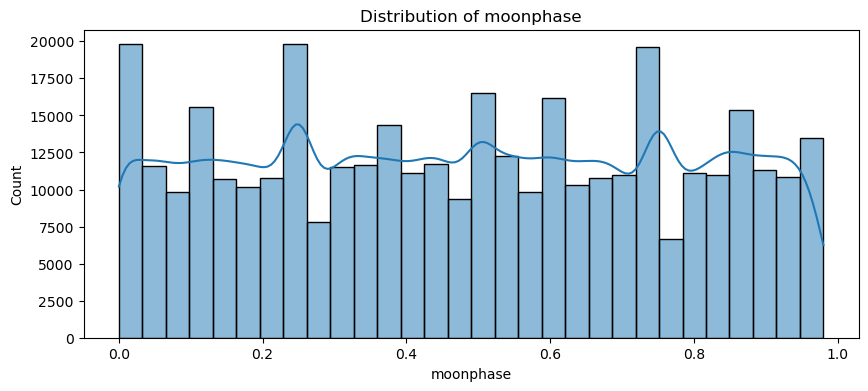

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


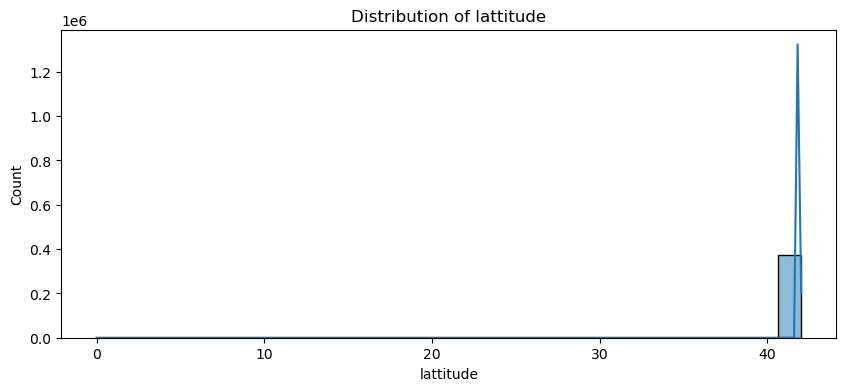

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


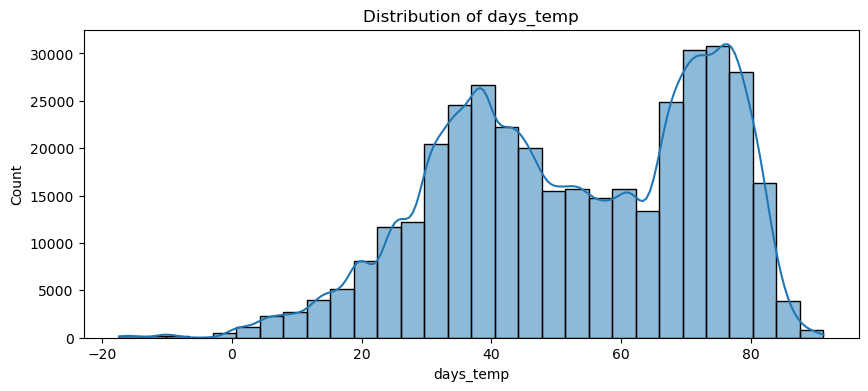

c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


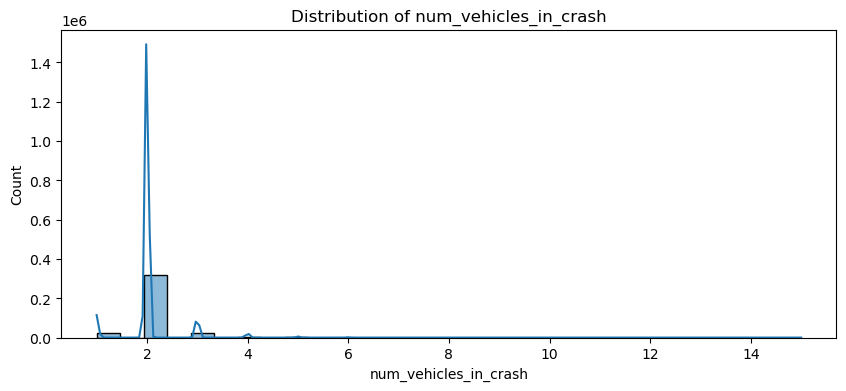

In [61]:
# List of features to visualize
features = ['windspeed', 'winddir', 'pressure', 'visibility', 
            'cloudcover', 'moonphase', 'lattitude', 
            'days_temp', 'num_vehicles_in_crash']

# 1️⃣ Countplot (for categorical/binned features)
plt.figure(figsize=(12, 6))
sns.countplot(x='num_vehicles_in_crash', data=X)  # Example for one categorical feature
plt.title('Count of Vehicles in Crash')
plt.show()

# 2️⃣ Histograms (for numeric features)
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

#### Defining the target variable

#### Mapping to deal convert string to numerics

In [27]:
# Encode crash_severity as numeric codes
df['crash_severity_class'] = df['crash_severity'].astype('category').cat.codes

# Check mapping
severity_mapping = dict(enumerate(df['crash_severity'].astype('category').cat.categories))
print("Severity Mapping:", severity_mapping)

Severity Mapping: {0: 'major', 1: 'minor'}


In [28]:
print(df["crash_severity_class"].dtype)

int8


In [29]:
df["crash_severity_class"].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
372057    False
372058    False
372059    False
372060    False
372061    False
Name: crash_severity_class, Length: 372062, dtype: bool

##### We have used the mapping function to convert strings to text and filled the missing values with 0 instead of coercing or one-hot encoding, we have then confired the data type after mapping and eventually checked for missing values. Next we define our target

In [30]:
# Features: all columns except the target
X = df.drop(columns=['crash_severity', 'crash_severity_class'])

# Target: crash severity class
y = df['crash_severity_class']

In [31]:
# Confirming our target  variable has been created
df.columns

Index(['id', 'crash_date', 'crash_time', 'town', 'city', 'state', 'country',
       'total_injured', 'total_killed', 'injury_incapacitated',
       'injury_non_incapacitated', 'most_severe_injury', 'crash_type',
       'contributory_cause', 'sec_contributory_cause', 'num_vehicles_in_crash',
       'crash_hit_and_run', 'crash_severity', 'traffic_control_device',
       'traffic_control_device_condition', 'road_defect', 'lattitude',
       'longitude', 'days_tempmax', 'days_tempmin', 'days_temp',
       'days_feelslikemax', 'days_feelslikemin', 'days_feelslike', 'days_dew',
       'days_humidity', 'days_precip', 'days_precipprob', 'days_precipcover',
       'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust',
       'days_windspeed', 'days_winddir', 'days_pressure', 'days_cloudcover',
       'days_visibility', 'days_uvindex', 'days_conditions', 'days_moonphase',
       'temp', 'feelslike', 'humidity', 'dew', 'precip', 'precipprob', 'snow',
       'snowdepth', 'precip_type',

##### We have defined our target by created a binary classification target 

#### Train_test split
We have split our data into feature and target 

In [32]:
# Drop the target and any columns you don't want as features
X = df.drop(columns=['crash_severity', 'crash_severity_class', 
                     'total_injured', 'total_killed'])

In [33]:
# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [47]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

In [48]:
# We split the dataset
target=X
feature=y

y = df['crash_severity_class']  # target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
# Remove duplicate column names in X_train
X_train = X_train.loc[:, ~X_train.columns.duplicated()]

# Remove duplicate column names in X_test
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

In [36]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Make sure the target is included
numeric_df['crash_severity_class'] = df['crash_severity_class'].astype(int)

In [ ]:
# List of selected features
model_features= [
    'windspeed',
    'winddir',
    'pressure',
    'visibility',
    'cloudcover',
    'moonphase',
    'lattitude',
    'days_temp',
    'num_vehicles_in_crash'
]

# Create the feature dataset
X = df[model_features].copy()

# Set the target variable
y = df['crash_severity_class']

# Optional: check the first few rows
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())


Features (X):
   windspeed  winddir  pressure  visibility  cloudcover  moonphase  lattitude  \
0        6.9    193.0    1013.9         1.8        54.6       0.56  41.998354   
1       11.4      3.0    1013.3         7.4        87.4       0.66  41.765266   
2       13.7     17.0    1013.6         9.9        58.2       0.66  41.902855   
3       13.7     17.0    1013.6         9.9        58.3       0.66  41.899822   
4        4.9    342.0    1018.4         9.9         0.0       0.69  41.844581   

   days_temp  num_vehicles_in_crash  
0       79.2                      3  
1       74.3                      2  
2       73.8                      2  
3       73.9                      2  
4       70.8                      2  

Target (y):
0    0
1    1
2    0
3    1
4    0
Name: crash_severity_class, dtype: int8


##### We split the dataset into training data and testing data 80% and 20% respectively . This prevents the model from seeing the test data during training

In [49]:
print(X.shape)

(372062, 9)


In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Plotting a heatmap

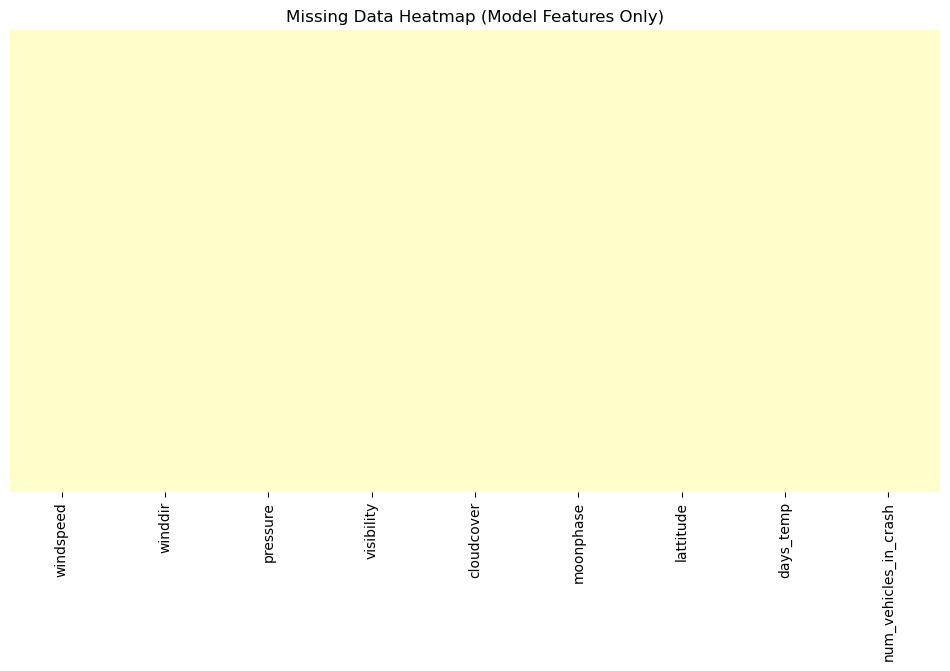

In [38]:
plt.figure(figsize=(12, 6))

# Use df[model_features] to look only at your selected columns
sns.heatmap(df[model_features].isnull(), yticklabels=False, cbar=False, cmap="YlOrRd")

plt.title("Missing Data Heatmap (Model Features Only)")
plt.show()

##### The output from the heatmap shows our predictors do not have any missing values

#### Checking for outliers in the features

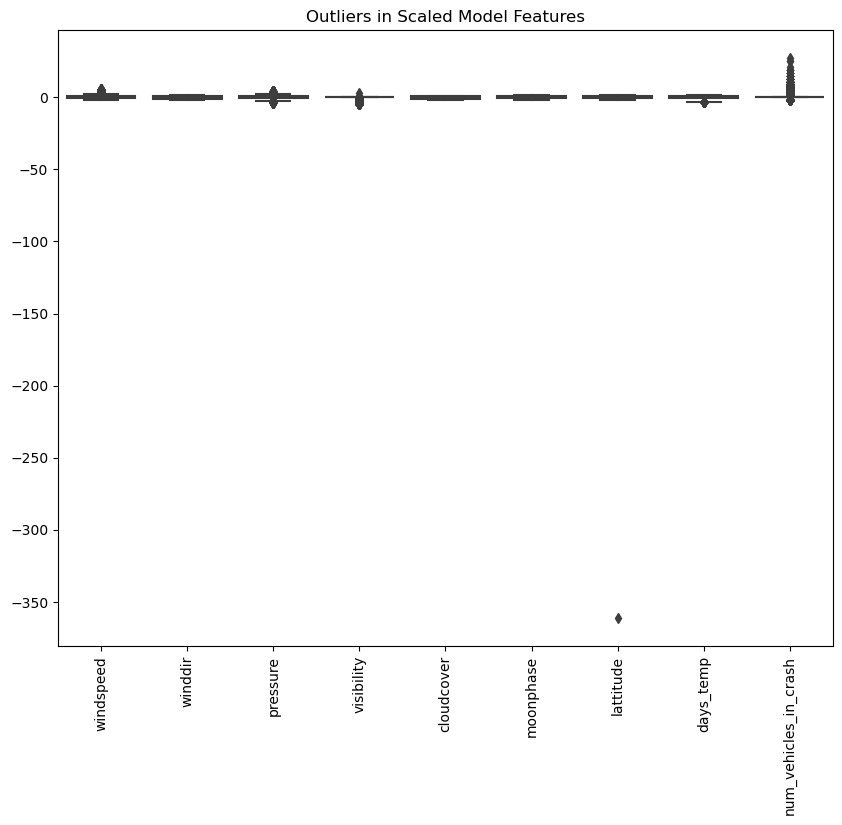

In [51]:
# Convert your scaled array back into a readable DataFrame
X_scaled_df = pd.DataFrame(X_train_scaled, columns=model_features)

# Create the plot
plt.figure(figsize=(10, 8))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=90)
plt.title("Outliers in Scaled Model Features")
plt.show()

#### Using IQR to check which predictors have outliers

In [ ]:
# Loop through each feature in your model_features list
for feature in model_features:
    # 1. Calculate IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Find outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    # 4. Print results
    print(f"Feature: {feature:25} | Outliers found: {len(outliers)}")

Feature: windspeed                 | Outliers found: 4277
Feature: winddir                   | Outliers found: 0
Feature: pressure                  | Outliers found: 6577
Feature: visibility                | Outliers found: 81549
Feature: cloudcover                | Outliers found: 0
Feature: moonphase                 | Outliers found: 0
Feature: lattitude                 | Outliers found: 1
Feature: days_temp                 | Outliers found: 199
Feature: num_vehicles_in_crash     | Outliers found: 51263


#### We are only deleting the lattitude outlier because we are using decision trees and deleting all these rows will destroy the predictiveness of our model

#### Dropping the lattitude outlier


In [ ]:
# 1. Define the "Normal" bounds for Chicago
# Chicago latitude is approximately between 41.6 and 42.1
min_lat = 41.0
max_lat = 43.0

# 2. Keep ONLY the rows that are inside these bounds
df_clean = df[(df['lattitude'] >= min_lat) & (df['lattitude'] <= max_lat)].copy()

# 3. Check how many rows were dropped
rows_dropped = len(df) - len(df_clean)
print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
print(f"Rows removed: {rows_dropped}")

# Now, use df_clean for all your future modeling!

Original row count: 372062
Cleaned row count: 372061
Rows removed: 1


#### The outlier row has been dropped

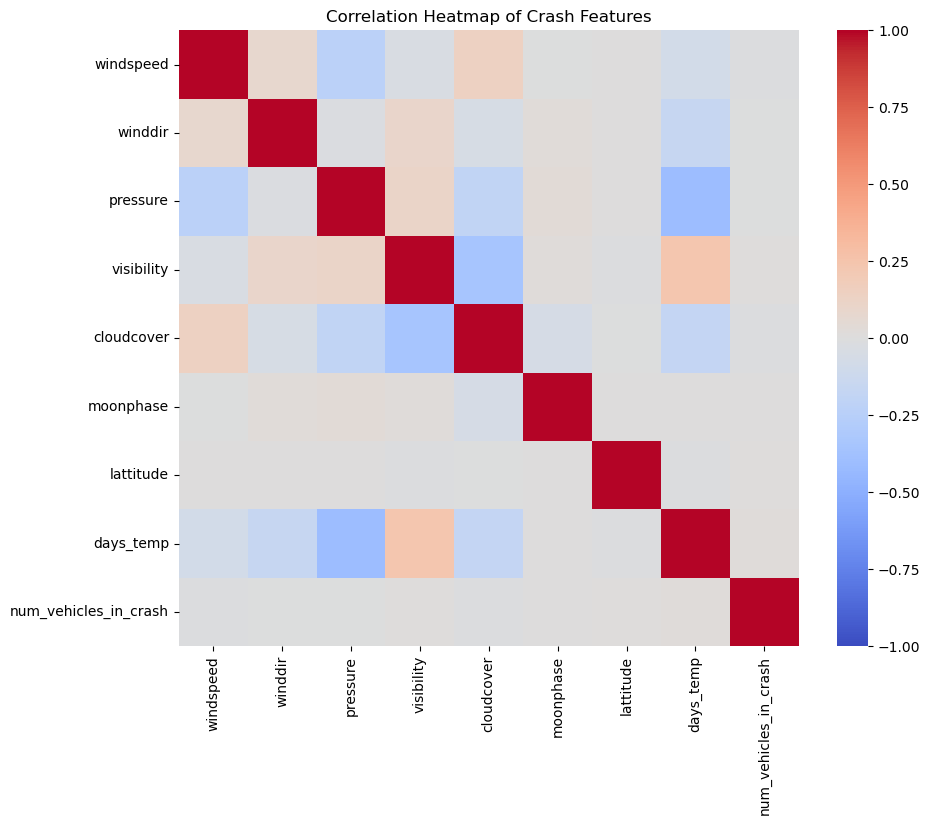

In [ ]:
# 1. Calculate the correlation matrix
# 'numeric_only=True' ensures we don't try to calculate correlation on text columns
corr_matrix = df[model_features].corr()

# 2. Set up the figure size so it's readable
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
# annot=False keeps it clean; 'coolwarm' shows negative (blue) and positive (red) correlations
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Heatmap of Crash Features")
plt.show()


#### We are using these relevant columns helps reduce noise and improve model performance

### Feature Scaling

In [ ]:
X_train = X_train[model_features]
X_test = X_test[model_features]

scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

Scaling standardizes the data so all features are on the same scale
- - Scaler fit only on training data
- - test data only transformed

#### Baseline Model- Logistic regression

In [52]:
log_model = LogisticRegression(max_iter=10000, class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [ ]:

scores = cross_val_score(log_model, X_train, y_train, cv=5)
print(scores.mean())

0.5099429284088618


#### Predictions

In [53]:
y_pred_log = log_model.predict(X_test_scaled)
print(y_pred_log)

[1 0 0 ... 1 1 1]


#### Uses the trained model to predict the outcomes for the test data

#### Model Evaluation
Accuracy

In [ ]:
accuracy_score(y_test, y_pred_log)

0.5248276510824722

#### Accuracy measures the proportion of the correct predictions

#### Confusion matrix

In [ ]:
confusion_matrix(y_test, y_pred_log)

array([[22788, 24001],
       [11358, 16266]], dtype=int64)

#### Shows prediction outcomes

#### Second model-decision tree

In [56]:
tree_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

##### We are using the max depth of 10 to avid overfitting

In [57]:

tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20
)

#### Predictions

In [58]:
y_pred_tree = tree_model.predict(X_test)
print(y_pred_tree)

[1 0 0 ... 1 1 1]


#### Evaluate tree model

In [59]:
accuracy_score(y_test, y_pred_tree)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.69      0.47      0.56     46789
           1       0.42      0.64      0.51     27624

    accuracy                           0.53     74413
   macro avg       0.55      0.56      0.53     74413
weighted avg       0.59      0.53      0.54     74413



#### Compare then models

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Logistic Regression Accuracy: 0.5248276510824722
Decision Tree Accuracy: 0.5326757421418301


#### A positive coefficient means that as that feature increases, the likelihood of an injury (1) increases. A negative coefficient means the likelihood of an injury decreases.

In [ ]:
# Create a dictionary to map feature names to their importance
coefficients = dict(zip(model_features, log_model.coef_[0]))

# Sort by importance
sorted_coefs = sorted(coefficients.items(), key=lambda x: abs(x[1]), reverse=True)

for feature, coef in sorted_coefs:
    print(f"{feature}: {coef:.4f}")

num_vehicles_in_crash: -0.2011
lattitude: 0.1566
windspeed: 0.0521
pressure: 0.0223
days_temp: 0.0150
visibility: -0.0105
cloudcover: -0.0095
moonphase: -0.0042
winddir: -0.0037


- Positive Coefficient: As this value goes up, the probability of an injury increases.

- Negative Coefficient: As this value goes up, the probability of an injury decreases.

In [ ]:
# Get feature importances from the tree
importances = tree_model.feature_importances_

# Sort and print them
for feature, importance in zip(model_features, importances):
    print(f"{feature}: {importance:.4f}")

windspeed: 0.0070
winddir: 0.0003
pressure: 0.0016
visibility: 0.0000
cloudcover: 0.0047
moonphase: 0.0003
lattitude: 0.1897
days_temp: 0.0016
num_vehicles_in_crash: 0.7947


Plotting the top predictors

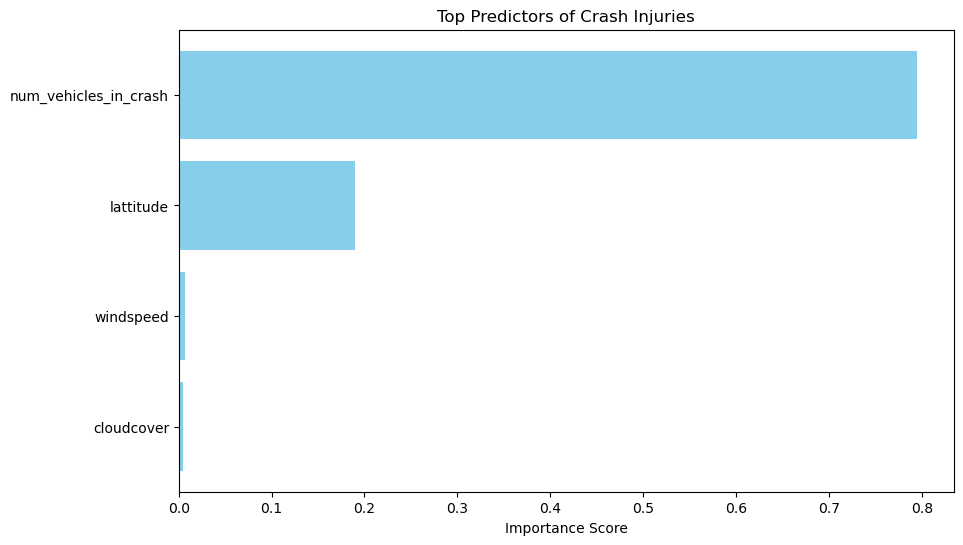

In [ ]:
plt.figure(figsize=(10, 6))
features = ['num_vehicles_in_crash', 'lattitude', 'windspeed', 'cloudcover']
scores = [0.7947, 0.1897, 0.0070, 0.0047]
plt.barh(features, scores, color='skyblue')
plt.title('Top Predictors of Crash Injuries')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

Calculating the ROC AUC scores

Logistic Regression AUC: 0.5510
Decision Tree AUC: 0.5802


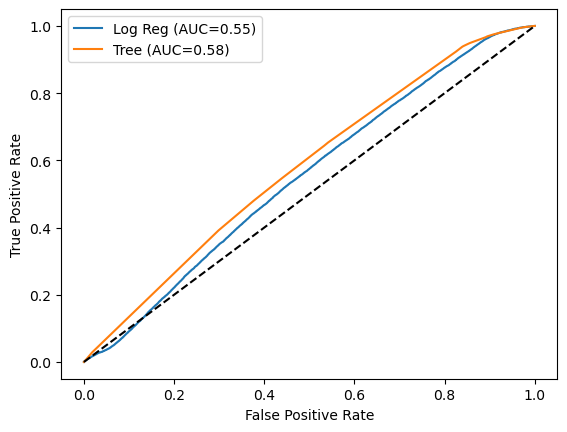

In [60]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

# 2. Calculate AUC scores
auc_log = roc_auc_score(y_test, y_prob_log)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"Logistic Regression AUC: {auc_log:.4f}")
print(f"Decision Tree AUC: {auc_tree:.4f}")

# 3. Plotting the ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.plot(fpr_log, tpr_log, label=f"Log Reg (AUC={auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Tree (AUC={auc_tree:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [67]:


# Define individual pipelines
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),        
    ('logreg', LogisticRegression(
        max_iter=5000, multi_class='multinomial', solver='lbfgs', class_weight='balanced'
    ))
])

tree_pipeline = Pipeline([
    ('tree', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

# Ensemble Voting Classifier
ensemble = VotingClassifier(
    estimators=[
        ('log', log_pipeline),
        ('tree', tree_pipeline),
        ('rf', rf_pipeline)
    ],
    voting='soft'  # use 'soft' to combine predicted probabilities
)

# Train ensemble
ensemble.fit(X_train, y_train)



VotingClassifier(estimators=[('log',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('logreg',
                                               LogisticRegression(class_weight='balanced',
                                                                  max_iter=5000,
                                                                  multi_class='multinomial'))])),
                             ('tree',
                              Pipeline(steps=[('tree',
                                               DecisionTreeClassifier(class_weight='balanced',
                                                                      random_state=42))])),
                             ('rf',
                              Pipeline(steps=[('rf',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      n_estimators=200,
                                                                      random_state=42))]))],
                 voting='soft')

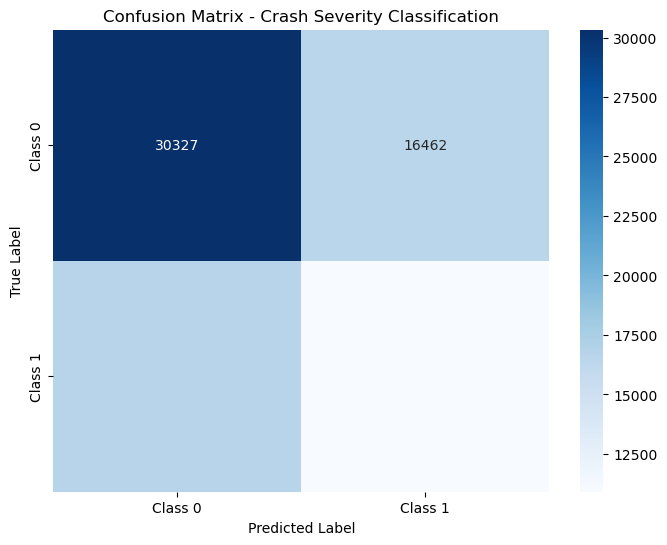

In [68]:
y_pred = ensemble.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in sorted(y.unique())],
            yticklabels=[f'Class {i}' for i in sorted(y.unique())])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Crash Severity Classification")
plt.show()

#### Indentifying the high-risk zones

In [ ]:
df_clean['lat_bin'] = pd.cut(df_clean['lattitude'], bins=10)

# Calculate the percentage of injuries in each bin
risk_map = df_clean.groupby('lat_bin')['crash_severity_class'].mean().sort_values(ascending=False)
print("Injury Risk by Latitude Belt:")
print(risk_map)

Injury Risk by Latitude Belt:
lat_bin
(41.985, 42.023]    0.430519
(41.909, 41.947]    0.414523
(41.947, 41.985]    0.393477
(41.872, 41.909]    0.378305
(41.834, 41.872]    0.377348
(41.682, 41.72]     0.352834
(41.644, 41.682]    0.352393
(41.72, 41.758]     0.335382
(41.796, 41.834]    0.334134
(41.758, 41.796]    0.330493
Name: crash_severity_class, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15868\2906549935.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_map = df_clean.groupby('lat_bin')['crash_severity_class'].mean().sort_values(ascending=False)


##### The far north you travel the higer the risk of an accident with 43%

### Recommendation

1. Since num_vehicles_in_crash is your strongest predictor,the city should prioritize on conflict point reduction. By converting high crash intersections into  round abouts or adding more signals. This will slow the speed of the cars and drivers will have ample time for reaction as well as reduce the number of injuries.

2. For location safety, because lattitude is a significant, the city should investigate the specific streets within the high risk lattitude zones. Then enforce speed cameras or increased patrols officers.

3. The city should issue amber alerts when there are changes in weather conditions, because different drivers react differently as well as focus on infustructure diring these weather changes

4. The city should intergrate an emergency dipatch system. This is because we a 69% recall, which flags when a crash is likely to have an injury. 

#### Conclusion
While a standard model prioritizes on accuracy, we optimized for recall. The model reveals thst the more the cars at in interserctions the higher the impact of accidents.
The city should focus on multi vehicle intersections within the high risk lattitude and the allocate resources where they will have immediate impact on saving lives